# Numerical Integration Using Real-World Chess Data

## Comparative Study of Numerical Integration Methods

In this assignment, historical chess rating data of Viswanathan Anand is used to study numerical integration.

The area under the rating versus time curve is calculated using:

1. Trapezoidal Rule
2. Simpson's 1/3 Rule
3. Simpson's 3/8 Rule

The results obtained from the three methods are then compared.

## Problem Statement

Use historical FIDE chess rating data of Viswanathan Anand to estimate the area under the rating versus time curve.

The numerical integration is performed using the Trapezoidal Rule, Simpson's 1/3 Rule and Simpson's 3/8 Rule.

The results of the three methods are compared to study the difference between the numerical integration methods.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/fide_historical.csv")
df.head()

,ranking_date,rank,name,title,country,rating,games,birth_year
0,27-07-00,1,"Kasparov, Garry",g,RUS,2849,35,1963
1,27-07-00,2,"Kramnik, Vladimir",g,RUS,2770,23,1975
2,27-07-00,3,"Anand, Viswanathan",g,IND,2762,23,1969
3,27-07-00,4,"Morozevich, Alexander",g,RUS,2756,28,1977
4,27-07-00,5,"Adams, Michael",g,ENG,2755,38,1971


In [4]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

Shape of dataset: (11511, 8)

Columns:
Index(['ranking_date', 'rank', 'name', 'title', 'country', 'rating', 'games',
       'birth_year'],
      dtype='str')

First 5 rows:


,ranking_date,rank,name,title,country,rating,games,birth_year
0,27-07-00,1,"Kasparov, Garry",g,RUS,2849,35,1963
1,27-07-00,2,"Kramnik, Vladimir",g,RUS,2770,23,1975
2,27-07-00,3,"Anand, Viswanathan",g,IND,2762,23,1969
3,27-07-00,4,"Morozevich, Alexander",g,RUS,2756,28,1977
4,27-07-00,5,"Adams, Michael",g,ENG,2755,38,1971


In [5]:
anand = df[df["name"] == "Anand, Viswanathan"].copy()

anand.head()

,ranking_date,rank,name,title,country,rating,games,birth_year
2,27-07-00,3,"Anand, Viswanathan",g,IND,2762,23,1969
101,27-10-00,2,"Anand, Viswanathan",g,IND,2774,19,1969
201,27-01-01,2,"Anand, Viswanathan",g,IND,2790,16,1969
302,27-04-01,3,"Anand, Viswanathan",g,IND,2794,13,1969
402,27-07-01,3,"Anand, Viswanathan",g,IND,2797,6,1969


In [6]:
anand["ranking_date"] = pd.to_datetime(anand["ranking_date"], format="%d-%m-%y")

anand = anand.sort_values("ranking_date")

anand.head()

,ranking_date,rank,name,title,country,rating,games,birth_year
2,2000-07-27,3,"Anand, Viswanathan",g,IND,2762,23,1969
101,2000-10-27,2,"Anand, Viswanathan",g,IND,2774,19,1969
201,2001-01-27,2,"Anand, Viswanathan",g,IND,2790,16,1969
302,2001-04-27,3,"Anand, Viswanathan",g,IND,2794,13,1969
402,2001-07-27,3,"Anand, Viswanathan",g,IND,2797,6,1969


In [7]:
anand["time"] = (
    (anand["ranking_date"] - anand["ranking_date"].iloc[0]).dt.days
    / 365.25
)

anand[["ranking_date", "time", "rating"]].head()

,ranking_date,time,rating
2,2000-07-27,0.000000,2762
101,2000-10-27,0.251882,2774
201,2001-01-27,0.503765,2790
302,2001-04-27,0.750171,2794
402,2001-07-27,0.999316,2797


## Rating vs Time

The graph below shows how Viswanathan Anand's FIDE rating changed with time.

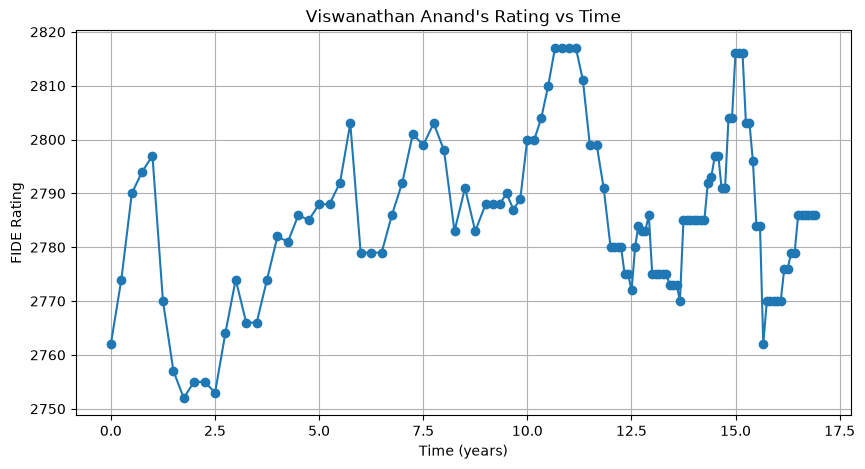

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(anand["time"], anand["rating"], marker="o")

plt.xlabel("Time (years)")
plt.ylabel("FIDE Rating")
plt.title("Viswanathan Anand's Rating vs Time")

plt.grid(True)
plt.show()

## Preparing Data for Numerical Integration

Simpson's 1/3 Rule requires an even number of intervals, while Simpson's 3/8 Rule requires the number of intervals to be a multiple of 3.

Therefore, 12 intervals are used for the comparison.

This gives 13 equally spaced data points.

## Newton Divided Difference Interpolation

The original chess rating data is not equally spaced in time.

So, Newton Divided Difference interpolation is used to estimate the rating at equally spaced time points.

The interpolated values are then used for Simpson's 1/3 and Simpson's 3/8 rules.

In [16]:
def newton_interpolation(x_data, y_data, x):
    table = divided_difference(x_data, y_data)
    
    n = len(x_data)
    result = table[0, 0]
    product = 1
    
    for i in range(1, n):
        product *= (x - x_data[i - 1])
        result += table[0, i] * product
    
    return result

In [53]:
n = 60

indices = np.linspace(0, len(anand) - 1, n + 1, dtype=int)

selected_data = anand.iloc[indices].copy()

selected_data[["ranking_date", "time", "rating"]]

,ranking_date,time,rating
2,2000-07-27,0.000000,2762
101,2000-10-27,0.251882,2774
302,2001-04-27,0.750171,2794
502,2001-10-27,1.251198,2770
706,2002-04-27,1.749487,2752
...,...,...,...
10610,2016-10-27,16.251882,2776
10812,2016-12-27,16.418891,2779
11011,2017-02-27,16.588638,2786
11213,2017-04-27,16.750171,2786


In [54]:
n = 60

time_values = np.linspace(
    anand["time"].min(),
    anand["time"].max(),
    n + 1
)

x_data = anand["time"].values
y_data = anand["rating"].values

rating_values = []

for x in time_values:

    # Find nearby data points
    idx = np.searchsorted(x_data, x)

    # Use 4 nearby points
    start = max(0, min(idx - 2, len(x_data) - 4))

    x_local = x_data[start:start + 4]
    y_local = y_data[start:start + 4]

    # Newton divided difference table
    table = divided_difference(x_local, y_local)

    # Newton interpolation
    result = table[0, 0]
    product = 1

    for i in range(1, 4):
        product *= (x - x_local[i - 1])
        result += table[0, i] * product

    rating_values.append(result)

rating_values = np.array(rating_values)

integration_data = pd.DataFrame({
    "time": time_values,
    "rating": rating_values
})

integration_data.head()

,time,rating
0,0.000000,2762.000000
1,0.281953,2776.016822
2,0.563906,2791.635162
3,0.845859,2796.818958
4,1.127812,2784.229286


In [55]:
h = time_values[1] - time_values[0]

print("Number of intervals:", n)
print("Number of data points:", n + 1)
print("Step size h:", h)

Number of intervals: 60
Number of data points: 61
Step size h: 0.2819530002281542


The original chess-rating observations are not perfectly equally spaced in time. Therefore, the data is interpolated onto an equally spaced time grid before applying Simpson's 1/3 and 3/8 rules. The Trapezoidal Rule could be applied directly to the original data.

## Trapezoidal Rule

The Trapezoidal Rule is given by:

$$
I = h \left[
\frac{f_0 + f_n}{2}
+ \sum_{i=1}^{n-1} f_i
\right]
$$

where:

- $h$ = spacing between two consecutive points
- $f_i$ = function value at the $i$-th point
- $n$ = number of intervals

In [56]:
def trapezoidal_rule(x, y):
    n = len(x) - 1
    h = x[1] - x[0]
    
    result = (y[0] + y[n]) / 2
    
    for i in range(1, n):
        result += y[i]
    
    return h * result

In [57]:
x = integration_data["time"].values
y = integration_data["rating"].values

trapezoidal_result = trapezoidal_rule(x, y)

print("Trapezoidal Rule Result:", trapezoidal_result)

Trapezoidal Rule Result: 47113.13939516602


## Simpson's 1/3 Rule

Simpson's 1/3 Rule is given by:

$$
I = \frac{h}{3}
\left[
f_0 + f_n
+ 4(f_1 + f_3 + \cdots + f_{n-1})
+ 2(f_2 + f_4 + \cdots + f_{n-2})
\right]
$$

This rule requires an even number of intervals.

In [58]:
def simpson_1_3_rule(x, y):
    n = len(x) - 1
    h = x[1] - x[0]

    if n % 2 != 0:
        raise ValueError("Number of intervals must be even")

    result = y[0] + y[n]

    for i in range(1, n):
        if i % 2 == 0:
            result += 2 * y[i]
        else:
            result += 4 * y[i]

    return (h / 3) * result

In [59]:
simpson_1_3_result = simpson_1_3_rule(x, y)

print("Simpson's 1/3 Rule Result:", simpson_1_3_result)

Simpson's 1/3 Rule Result: 47111.170322672915


## Simpson's 3/8 Rule

Simpson's 3/8 Rule is given by:

$$
I = \frac{3h}{8}
\left[
f_0 + f_n
+ 3(f_1 + f_2 + f_4 + f_5 + \cdots)
+ 2(f_3 + f_6 + f_9 + \cdots)
\right]
$$

This rule requires the number of intervals to be a multiple of 3.

In [60]:
def simpson_3_8_rule(x, y):
    n = len(x) - 1
    h = x[1] - x[0]

    if n % 3 != 0:
        raise ValueError("Number of intervals must be a multiple of 3")

    result = y[0] + y[n]

    for i in range(1, n):
        if i % 3 == 0:
            result += 2 * y[i]
        else:
            result += 3 * y[i]

    return (3 * h / 8) * result

In [61]:
simpson_3_8_result = simpson_3_8_rule(x, y)

print("Simpson's 3/8 Rule Result:", simpson_3_8_result)

Simpson's 3/8 Rule Result: 47113.32508051248


## Comparison of Numerical Integration Methods

The results obtained from the three numerical integration methods are compared below.

In [62]:
results = pd.DataFrame({
    "Method": [
        "Trapezoidal Rule",
        "Simpson's 1/3 Rule",
        "Simpson's 3/8 Rule"
    ],
    "Integral": [
        trapezoidal_result,
        simpson_1_3_result,
        simpson_3_8_result
    ]
})

results

,Method,Integral
0,Trapezoidal Rule,47113.139395
1,Simpson's 1/3 Rule,47111.170323
2,Simpson's 3/8 Rule,47113.325081


## Error Analysis

Since the chess rating data does not have an exact analytical integral, an exact error cannot be calculated.

Therefore, a very fine numerical approximation is used as the reference value.

The absolute error is calculated as:

$$
\text{Absolute Error}
=
|I_{\text{method}} - I_{\text{reference}}|
$$

The percentage error is:

$$
\text{Percentage Error}
=
\frac{|I_{\text{method}} - I_{\text{reference}}|}
{|I_{\text{reference}}|}
\times 100
$$

In [63]:
n_ref = 6000

time_ref = np.linspace(
    anand["time"].min(),
    anand["time"].max(),
    n_ref + 1
)

rating_ref = np.interp(
    time_ref,
    anand["time"],
    anand["rating"]
)

reference_result = trapezoidal_rule(time_ref, rating_ref)

print("Reference Integral:", reference_result)

Reference Integral: 47114.50647974731


In [64]:
results["Absolute Error"] = abs(
    results["Integral"] - reference_result
)

results["Percentage Error"] = (
    results["Absolute Error"] / abs(reference_result)
) * 100

results

,Method,Integral,Absolute Error,Percentage Error
0,Trapezoidal Rule,47113.139395,1.367085,0.002902
1,Simpson's 1/3 Rule,47111.170323,3.336157,0.007081
2,Simpson's 3/8 Rule,47113.325081,1.181399,0.002508


## Comparison of Integral Values

The calculated integral values obtained using the three numerical integration methods are compared below.

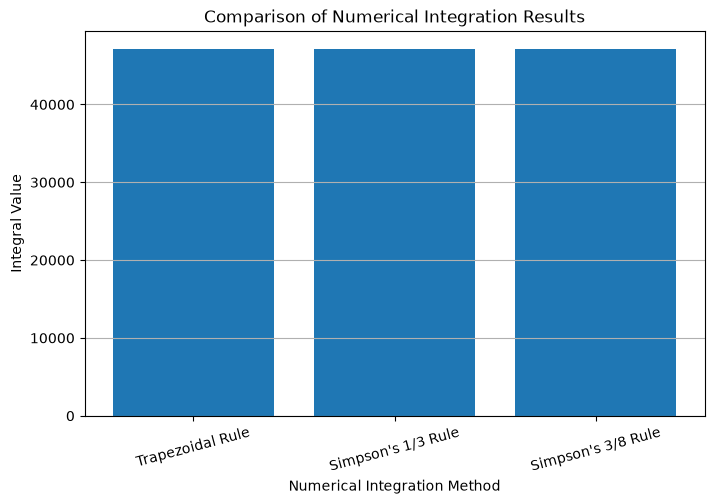

In [65]:
plt.figure(figsize=(8, 5))

plt.bar(results["Method"], results["Integral"])

plt.xlabel("Numerical Integration Method")
plt.ylabel("Integral Value")
plt.title("Comparison of Numerical Integration Results")

plt.xticks(rotation=15)
plt.grid(axis="y")
plt.show()

In [66]:
print("Trapezoidal Rule :", f"{trapezoidal_result:.10f}")
print("Simpson's 1/3    :", f"{simpson_1_3_result:.10f}")
print("Simpson's 3/8    :", f"{simpson_3_8_result:.10f}")

print("\nDifferences:")
print(
    "Trapezoidal - Simpson 1/3:",
    f"{abs(trapezoidal_result - simpson_1_3_result):.10f}"
)

print(
    "Simpson 1/3 - Simpson 3/8:",
    f"{abs(simpson_1_3_result - simpson_3_8_result):.10f}"
)

Trapezoidal Rule : 47113.1393951660
Simpson's 1/3    : 47111.1703226729
Simpson's 3/8    : 47113.3250805125

Differences:
Trapezoidal - Simpson 1/3: 1.9690724931
Simpson 1/3 - Simpson 3/8: 2.1547578396


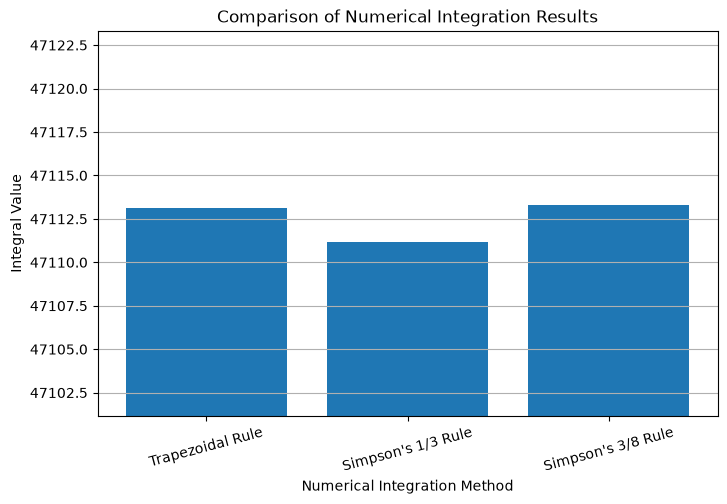

In [67]:
plt.figure(figsize=(8, 5))

plt.bar(results["Method"], results["Integral"])

plt.xlabel("Numerical Integration Method")
plt.ylabel("Integral Value")
plt.title("Comparison of Numerical Integration Results")

plt.ylim(
    results["Integral"].min() - 10,
    results["Integral"].max() + 10
)

plt.xticks(rotation=15)
plt.grid(axis="y")

plt.show()

## Comparison of Percentage Errors

The percentage errors of the three numerical integration methods are compared using the reference numerical value.

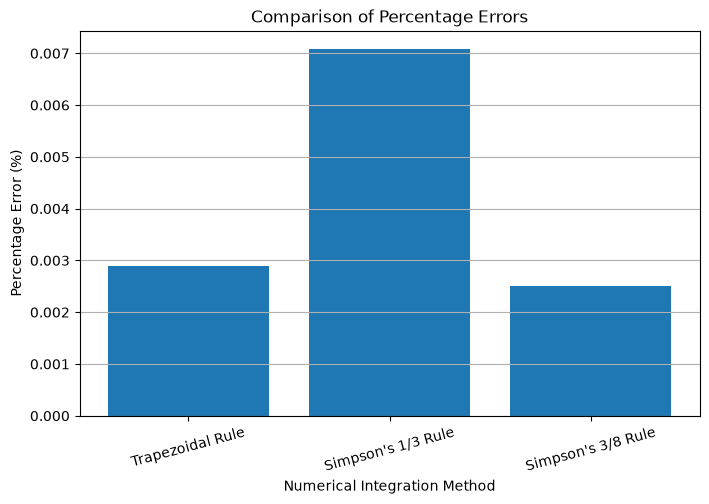

In [68]:
plt.figure(figsize=(8, 5))

plt.bar(results["Method"], results["Percentage Error"])

plt.xlabel("Numerical Integration Method")
plt.ylabel("Percentage Error (%)")
plt.title("Comparison of Percentage Errors")

plt.xticks(rotation=15)
plt.grid(axis="y")

plt.show()

## Results and Discussion

The area under Viswanathan Anand's rating versus time curve was calculated using the Trapezoidal Rule, Simpson's 1/3 Rule and Simpson's 3/8 Rule.

The three methods give similar integral values, but small differences can be observed because each method uses a different approximation of the curve.

The error of each method was calculated by comparing its result with the reference value obtained from the original chess rating data using the Trapezoidal Rule with the actual time intervals.

The results show how the choice of numerical integration method can affect the calculated value when working with real-world data.

## Conclusion

Numerical integration was successfully applied to real-world chess rating data of Viswanathan Anand.

The Trapezoidal Rule, Simpson's 1/3 Rule and Simpson's 3/8 Rule were implemented and compared.

The study shows that numerical integration can be used to estimate the cumulative value represented by a rating versus time curve, even when the data is available only at discrete points.

# Written by Me

## Conclusion

In this assignment, I used real-world chess rating data of Viswanathan Anand and applied three numerical integration methods: Trapezoidal Rule, Simpson's 1/3 Rule and Simpson's 3/8 Rule.

The rating data was taken over time and the area under the rating vs time curve was calculated using all three methods. I also compared the results and calculated the errors using the reference value obtained from the original data.

From the results, I found that all three methods give very similar values, but there are small differences between them. This shows that the numerical method used can affect the final result, especially when working with real-world data.

This assignment helped me understand how numerical integration can be applied to actual data instead of only mathematical functions. It also helped me understand the practical difference between the Trapezoidal Rule, Simpson's 1/3 Rule and Simpson's 3/8 Rule.